# CSC4010Z Assignment 2: Encoder-Decoder Models for Grapheme-to-Phoneme Conversion

---

- **Author:** Siyabonga Madondo
- **Student Number:** MDNSIY014
- **Date:** 18 May 2026

---

A *grapheme* is the smallest unit of written language, while a *phoneme* is the smallest unit of sound in a language. Grapheme-to-Phoneme (G2P) conversion is the task of mapping written words to their pronunciation. G2P conversion is a core component of many systems, including text-to-speech (TTS) and automatic speech recognition (ASR), and can be framed as a sequence-to-sequence (Seq2Seq) task.

In this assignment, we implement an LSTM encoder-decoder model in three configurations:
1. Using no context vector
2. Using the final encoder hidden state $h_n$ as a context vector at every decoder step
3. Computing the context vector dynamically using *cross-attention* at every decoder step.

Using G2P conversion as the task, we train and evaluate each variant on the **CMU Pronouncing Dictionary (CMUdict)** to compare their performance. This allows us to observe the *hidden state bottleneck* and see how *attention* overcomes it.

**Generative AI Statement:**

# Setting Up
---

Package installations, imports, reproducibility seeds (42) and device configuration.

In [2]:
import os, sys, csv, random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.use_deterministic_algorithms(True, warn_only=True)

# Check CUDA availability
if torch.cuda.is_available():
    device = torch.device('cuda')  
    torch.cuda.manual_seed_all(SEED)
elif torch.backends.mps.is_available():
    device = torch.device('mps')
    torch.mps.manual_seed(SEED)
else:
    device = torch.device('cpu')

print(f"Python Version: {sys.version}\nPyTorch Version: {torch.__version__}\nUsing Device: {device}")

Python Version: 3.9.6 (default, Dec  2 2025, 07:27:58) 
[Clang 17.0.0 (clang-1700.6.3.2)]
PyTorch Version: 2.8.0
Using Device: mps


# 1. Dataset Processing
---

We use the **CMUdict** dataset, a lexicon of ~134,000 North American English words and their ARPAbet phoneme transcriptions. We use the following splits as specified in the guidelines:

| File | Words | Description |
|------|-------|-------------|
| `g2p_train.csv` | 92,426 | Training set |
| `g2p_val.csv` | 11,553 | Validation set |
| `g2p_test.csv` | 11,554 | Test set |

Each split is processed as follows:

1. Load words and phoneme sequences from the CSV file
2. Build character and phoneme vocabularies from the training split only
3. Encode each (word, phoneme) pair as integer index sequences, with `<SOS>` prepended and `<EOS>` appended to each target sequence

### Data Loading & Preprocessing

In [3]:
# Constant Values
SPECIAL_TOKENS = ['<PAD>', '<SOS>', '<EOS>', '<UNK>']

def load_data(filepath: str):
    """Load a G2P CSV file, returning words and their phoneme sequences."""
    data = []
    
    # Check if the file exists
    if not os.path.exists(filepath):
        raise FileNotFoundError(f"Dataset file not found: {filepath}")

    # Open and read the file
    with open(filepath, 'r', encoding='utf-8') as f:
        reader = csv.DictReader(f)
        for row in reader:
            data.append(row)

    # Check if data successfully read
    if not data:
        raise ValueError(f"No data loaded from: {filepath}")
    
    # Extract all words and phonemes from the data
    words  = [entry['word'] for entry in data]
    phonemes = [entry['phonemes'].split() for entry in data]

    return words, phonemes

def build_character_vocabulary(words: list[str]):
    """Build the character vocabulary from the given list of words."""
    # Extract the characters from the word list and append the special tokens to the start
    characters = sorted(set(character for word in words for character in word))
    vocabulary = SPECIAL_TOKENS + characters

    # Map each character to an index and each index to a character
    character_to_index = {character: index for index, character in enumerate(vocabulary)}
    index_to_character = {index: character for character, index in character_to_index.items()}

    return character_to_index, index_to_character

def build_phoneme_vocabulary(phonemes: list[list[str]]):
    """Build the phoneme vocabulary from the given list of phonemes."""
    # Convert the list of phoneme sequences into a flat list of phonemes
    flat_phonemes = [phoneme for sequence in phonemes for phoneme in sequence]

    # Extract the phonemes from the phoneme list and append the special tokens to the start
    phonemes_sorted = sorted(set(flat_phonemes))
    vocabulary = SPECIAL_TOKENS + phonemes_sorted

    # Map each phoneme to a index and each index to a phoneme
    phoneme_to_index = {phoneme: index for index, phoneme in enumerate(vocabulary)}
    index_to_phoneme = {index: phoneme for phoneme, index in phoneme_to_index.items()}

    return phoneme_to_index, index_to_phoneme

# Load all splits
g2p_train_words, g2p_train_phonemes = load_data('../data/g2p_train.csv')
g2p_val_words, g2p_val_phonemes = load_data('../data/g2p_val.csv')
g2p_test_words, g2p_test_phonemes = load_data('../data/g2p_test.csv')

print("Datasets successfully loaded!")

# Build words and phoneme vocabularies for the training split
g2p_character_to_index, g2p_index_to_character = build_character_vocabulary(g2p_train_words)
g2p_phoneme_to_index, g2p_index_to_phoneme = build_phoneme_vocabulary(g2p_train_phonemes)

print("Word and phoneme vocabularies successfully initialised!")

Datasets successfully loaded!
Word and phoneme vocabularies successfully initialised!


### `G2PDataset` Class Definition

We define the `G2PDataset`, which encodes each G2P `(word, phoneme)` pair as integer index sequences. 

In [4]:
class G2PDataset(torch.utils.data.Dataset):
    """Dataset that encodes each G2P (word, phoneme) pair as integer index sequences."""

    def __init__(self, words: list[str], phonemes: list[list], g2p_character_to_index: dict[str, int], g2p_phoneme_to_index: dict[str, int]):
        """Initialise the G2PDataset with words, phoneme sequences, and vocabulary mappings."""
        self.words = words
        self.phonemes = phonemes
        self.character_to_index = g2p_character_to_index
        self.phoneme_to_index = g2p_phoneme_to_index

    def __getitem__(self, index: int):
        """Return the encoded (word, phoneme) pair at the given index as torch tensors."""
        # Obtain the word and its associated phoneme at the given index
        word = self.words[index]
        phonemes = self.phonemes[index]

        # Encode word characters as indices, with <EOS> appended
        unknown_index = self.character_to_index['<UNK>']
        word_indices = [self.character_to_index.get(character, unknown_index) for character in word]

        # Encode phoneme sequence with <SOS> prepended and <EOS> appended
        phoneme_indices = [self.phoneme_to_index['<SOS>']]
        phoneme_indices += [self.phoneme_to_index.get(phoneme, self.phoneme_to_index['<UNK>']) for phoneme in phonemes]
        phoneme_indices += [self.phoneme_to_index['<EOS>']]

        return torch.tensor(word_indices), torch.tensor(phoneme_indices)

    def __len__(self):
        "Return the number of samples in the dataset."
        return len(self.words)

### `DataLoaders` \& `collate_fn`

We implement `collate_fn` and use it to create `DataLoaders` with padded sequences in each batch.

In [ ]:
# Constant Values
BATCH_SIZE = 64

def collate_fn(batch):
    """Pad word and phoneme sequences in a batch to the same length, with <PAD> = 0."""
    word_tensors, phoneme_tensors = zip(*batch)

    # Pad source (word) sequences to the longest word in the batch
    word_tensors_padded = pad_sequence(word_tensors, batch_first=True, padding_value=0)

    # Pad target (phoneme) sequences to the longest phoneme sequence
    phoneme_tensors_padded = pad_sequence(phoneme_tensors, batch_first=True, padding_value=0)

    return word_tensors_padded, phoneme_tensors_padded

# Create Datasets for each split 
g2p_train_dataset = G2PDataset(g2p_train_words, g2p_train_phonemes, g2p_character_to_index, g2p_phoneme_to_index)
g2p_val_dataset = G2PDataset(g2p_val_words, g2p_val_phonemes, g2p_character_to_index, g2p_phoneme_to_index)
g2p_test_dataset = G2PDataset(g2p_test_words, g2p_test_phonemes, g2p_character_to_index, g2p_phoneme_to_index)
print("Datasets created successfully!")

# Create Data Loaders for each split
g2p_train_loader = DataLoader(g2p_train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
g2p_val_loader = DataLoader(g2p_val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
g2p_test_loader = DataLoader(g2p_test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
print("Data Loaders created successfully!")


Datasets created successfully!
Data Loaders created successfully!
Character vocabulary size : 30
Phoneme vocabulary size   : 73
Train samples: 92426
Val samples  : 11553
Test samples : 11554


### Data Exploration

Character vocabulary size : 30
Phoneme vocabulary size   : 73
Train samples: 92426
Validation samples  : 11553
Test samples : 11554


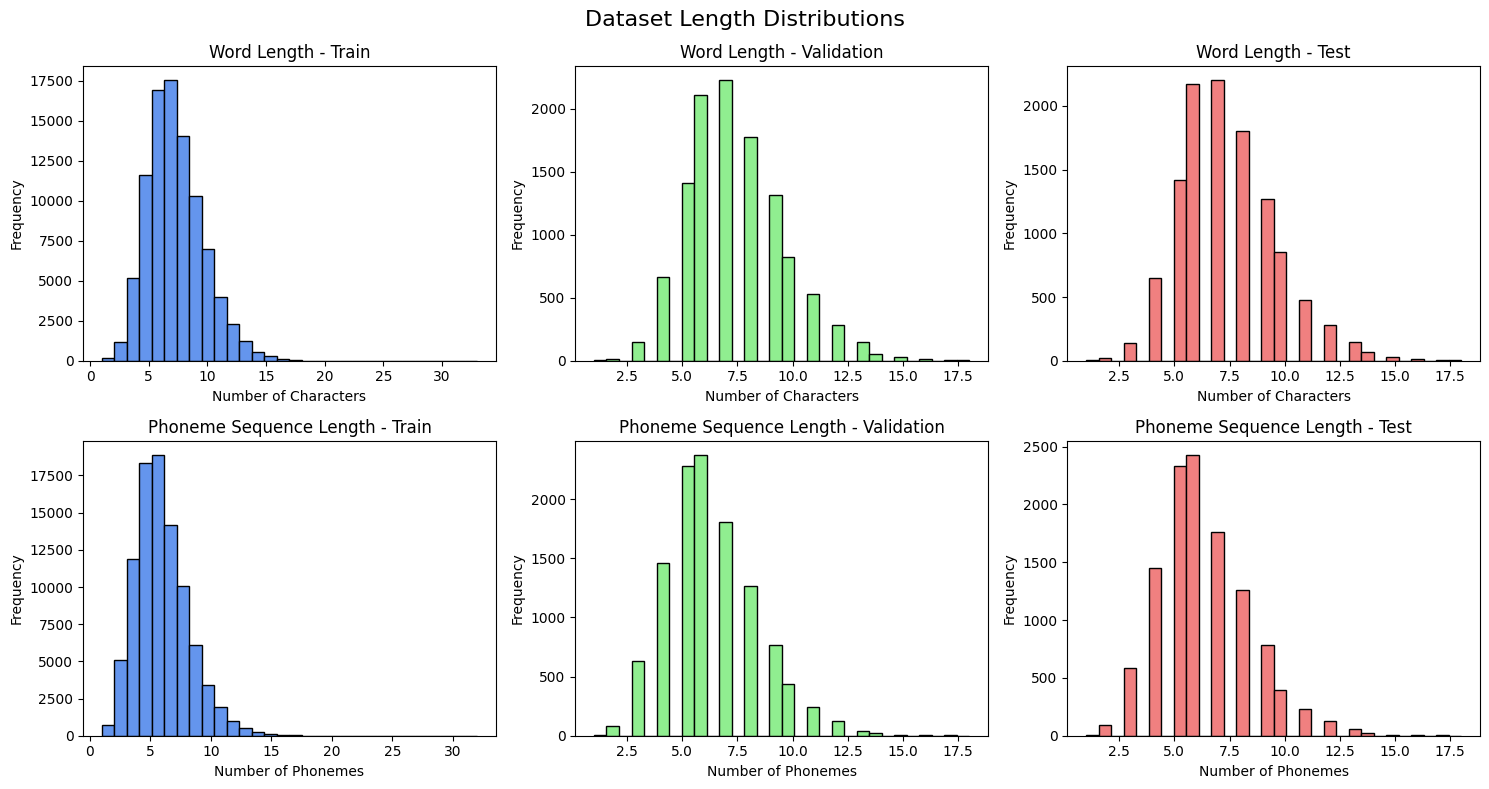

In [25]:
# Vocabulary & dataset sizes
print(f"Character vocabulary size : {len(g2p_character_to_index)}")
print(f"Phoneme vocabulary size   : {len(g2p_phoneme_to_index)}")
print(f"Train samples: {len(g2p_train_dataset)}")
print(f"Validation samples  : {len(g2p_val_dataset)}")
print(f"Test samples : {len(g2p_test_dataset)}")

# Compute lengths
train_word_lengths = [len(word) for word in g2p_train_words]
val_word_lengths = [len(word) for word in g2p_val_words]
test_word_lengths = [len(word) for word in g2p_test_words]

train_phoneme_lengths = [len(phoneme) for phoneme in g2p_train_phonemes]
val_phoneme_lengths   = [len(phoneme) for phoneme in g2p_val_phonemes]
test_phoneme_lengths  = [len(phoneme) for phoneme in g2p_test_phonemes]

# Plot histograms
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

fig.suptitle('Dataset Length Distributions', fontsize=16)

axes[0, 0].hist(train_word_lengths, bins=30, color='cornflowerblue', edgecolor='black')
axes[0, 1].hist(val_word_lengths,   bins=30, color='lightgreen', edgecolor='black')
axes[0, 2].hist(test_word_lengths,  bins=30, color='lightcoral', edgecolor='black')

axes[1, 0].hist(train_phoneme_lengths, bins=30, color='cornflowerblue', edgecolor='black')
axes[1, 1].hist(val_phoneme_lengths,   bins=30, color='lightgreen', edgecolor='black')
axes[1, 2].hist(test_phoneme_lengths,  bins=30, color='lightcoral', edgecolor='black')

# Add axis labels
for col, split in enumerate(['Train', 'Validation', 'Test']):
    axes[0, col].set_title(f'Word Length - {split}')
    axes[0, col].set_xlabel('Number of Characters')
    axes[0, col].set_ylabel('Frequency')

    axes[1, col].set_title(f'Phoneme Sequence Length - {split}')
    axes[1, col].set_xlabel('Number of Phonemes')
    axes[1, col].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# 2. LSTM Cell
---

Unlike a standard RNN, the **LSTM cell** maintains two states across timesteps: a hidden state, $h_t$ and a cell state $c_t$. These are controlled by *input, forget, and output gates*, which regulate information flow. We implement an LSTM cell from scratch in the `LSTMCell` class.

In [ ]:
class LSTMCell(nn.Module):
    """LSTM cell implementing the six LSTM gating equations."""

    def __init__(self, input_size: int, hidden_size: int):
        """
        Initialise the LSTM cell and its parameters.

        :param input_size: dimensionality of input x_t
        :param hidden_size: dimensionality of hidden state h_t and cell state c_t
        """
        super().__init__()
        self.hidden_size = hidden_size
        
        # Forget gate
        self.W_f = nn.Linear(input_size, hidden_size, bias=False)
        self.U_f = nn.Linear(hidden_size, hidden_size, bias=False)
        self.b_f = nn.Parameter(torch.zeros(hidden_size))
    
        # Input gate
        self.W_i = nn.Linear(input_size, hidden_size, bias=False)
        self.U_i = nn.Linear(hidden_size, hidden_size, bias=False)
        self.b_i = nn.Parameter(torch.zeros(hidden_size))
       
        # Output gate
        self.W_o = nn.Linear(input_size, hidden_size, bias=False)
        self.U_o = nn.Linear(hidden_size, hidden_size, bias=False)
        self.b_o = nn.Parameter(torch.zeros(hidden_size))
       
        # Cell content
        self.W_c = nn.Linear(input_size, hidden_size, bias=False)
        self.U_c = nn.Linear(hidden_size, hidden_size, bias=False)
        self.b_c = nn.Parameter(torch.zeros(hidden_size))
        
    def forward(self, x: torch.Tensor, h_prev: torch.Tensor, c_prev: torch.Tensor):
        """
        Compute one LSTM timestep.
        params:
            x:      input at current timestep, shape (batch, input_size)
            h_prev: previous hidden state,     shape (batch, hidden_size)
            c_prev: previous cell state,       shape (batch, hidden_size)
        returns:
            h: new hidden state, shape (batch, hidden_size)
            c: new cell state,   shape (batch, hidden_size)
        """
        f = torch.sigmoid(self.W_f(x) + self.U_f(h_prev) + self.b_f)
        i = torch.sigmoid(self.W_i(x) + self.U_i(h_prev) + self.b_i)
        o = torch.sigmoid(self.W_o(x) + self.U_o(h_prev) + self.b_o)
        c_tilde = torch.tanh(self.W_c(x) + self.U_c(h_prev) + self.b_c)
        c = f * c_prev + i * c_tilde
        h = o * torch.tanh(c)

        return h, c